# ESG Sustainability Analytics — Methodology (Steps 1–8)

**Pipeline:** Clean → Validate → Feature Engineering → EDA → Risk Index → Forecast → Validate & Explain → Segment

| Step | Name | Description |
|------|------|------|
| 1 | Clean | Remove structural issues from the raw CSV (index column, string-encoded lists, dtypes, duplicates) |
| 2 | Validate | Data-quality checks (score relationship, value ranges, missing values) |
| 3 | Features | Engineer new signal columns (text, composition, lag/time) |
| 4 | EDA | Visual insights (distributions, correlation, temporal trends, ranking) |
| 5 | Risk Index | Weighted composite ESG risk score + company ranking |
| 6 | Forecast | Leakage-safe next-year score prediction |
| 7 | Validate & Explain | Cross-validation, time-based out-of-sample test, permutation importance |
| 8 | Segment | Unsupervised KMeans segmentation of companies into ESG archetypes |

Input: `preprocessed_content.csv` — ESG dataset (866 rows × 10 columns, 263 S&P 500 companies, 2014–2023).

## 0. Setup â€” libraries + data load

In [1]:
import ast
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

RAW_PATH = "preprocessed_content.csv"
raw = pd.read_csv(RAW_PATH)
print("Raw shape:", raw.shape)
print("Columns:", raw.columns.tolist())
raw.head(3)

Raw shape: (866, 10)
Columns: ['Unnamed: 0', 'filename', 'ticker', 'year', 'preprocessed_content', 'ner_entities', 'e_score', 's_score', 'g_score', 'total_score']


,Unnamed: 0,filename,ticker,year,preprocessed_content,ner_entities,e_score,s_score,g_score,total_score
0,0,ASX_BSX_2020.pdf,BSX,2020,style guide colour colour use imagecolour prof...,"['bk%', 'rgb', 'un', 'el ectric mine consortiu...",3.16,18.00,11.83,32.98
1,1,ASX_BSX_2022.pdf,BSX,2022,sustainability report look mining green office...,"['murray street', 'west perth', 'west perth', ...",2.83,12.86,10.32,26.02
2,2,ASX_EXR_2022.pdf,EXR,2022,report environment social governance esg basel...,"['september', 'mongolia', 'australia', 'austra...",3.81,4.28,5.86,13.94


---
## STEP 1 â€” Data Cleaning
Raw CSV (866Ã—10) â†’ clean dataset (~864Ã—9)

Four tasks:
1. **Drop the index column** â€” `Unnamed: 0` is just a leftover pandas index
2. **Parse the entity lists** â€” `ner_entities` is stored as a string; convert it to a real Python list with `ast.literal_eval` (never `eval`, which is a code-execution risk)
3. **Standardize dtypes** â€” text via `.strip().upper()`, numerics via `pd.to_numeric(errors="coerce")`
4. **Remove duplicates** â€” the same `ticker+year` appears twice (a `(1)` filename variant)

In [2]:
df = raw.copy()

# drop the leftover pandas index column
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# ner_entities is a string-encoded list -> parse to a real Python list
# (ast.literal_eval, NOT eval -> avoids the code-execution risk)
def safe_parse_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    try:
        val = ast.literal_eval(x)
        return val if isinstance(val, list) else []
    except (ValueError, SyntaxError):
        return []

df["ner_entities"] = df["ner_entities"].apply(safe_parse_list)

# type standardization: strip/upper-case text, coerce numerics
df["ticker"]   = df["ticker"].astype(str).str.strip().str.upper()
df["filename"] = df["filename"].astype(str).str.strip()
for c in ["year", "e_score", "s_score", "g_score", "total_score"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["year"] = df["year"].astype("Int64")

print("After type-fix shape:", df.shape)

After type-fix shape: (866, 9)


In [3]:
# duplicate ticker+year rows -> keep only the first occurrence
dup_mask = df.duplicated(subset=["ticker", "year"], keep=False)
print("Duplicate ticker+year rows found:", int(dup_mask.sum()))
print(df.loc[dup_mask, ["filename", "ticker", "year"]].to_string())

df = df.drop_duplicates(subset=["ticker", "year"], keep="first").reset_index(drop=True)
clean = df
print()
print("[OK] Clean shape:", clean.shape)

Duplicate ticker+year rows found: 3
                 filename ticker  year
286     NYSE_ABT_2021.pdf    ABT  2021
861  TSX_ABT_2021 (1).pdf    ABT  2021
862      TSX_ABT_2021.pdf    ABT  2021

[OK] Clean shape: (864, 9)


---
## STEP 2 â€” Data Quality Checks
Clean data â†’ validated data (with documented assumptions)

Checks performed:
1. **Score relationship** â€” is `total_score â‰ˆ e + s + g`? (it is NOT an exact identity â€” only *approximately additive*)
2. **Gap magnitude** â€” how many rows are off by rounding-level amounts (â‰¤0.02) vs. more than that
3. **Regression proof** â€” coefficients â‰ˆ [1,1,1], RÂ² â‰ˆ 0.999 (additive & equal-weight)
4. **Range validation** â€” scores non-negative, years within 2014â€“2023
5. **Missing values** â€” count of blanks

> **Key finding:** the gap is **not just floating-point rounding** â€”
> rounding 2-decimal numbers explains at most ~0.015, yet ~22% of rows are off by more than that (max ~2.77).
> Therefore `total_score` is treated as an **approximately-additive, separately-reported figure**:
> compared with `np.isclose`/tolerance, and large-gap rows are flagged as **data-quality outliers**
> rather than dismissed as "just rounding".

In [4]:
# --- 1. Assumption check: total â‰ˆ e + s + g (approximately additive, NOT an exact identity) ---
recomputed = clean["e_score"] + clean["s_score"] + clean["g_score"]
diff = recomputed.sub(clean["total_score"]).abs()

exact_2dp    = (recomputed.round(2) == clean["total_score"].round(2)).mean() * 100
within_002   = (diff < 0.02).mean() * 100      # max gap attributable to pure float rounding
within_1     = (diff < 1.0).mean() * 100
beyond_round = int((diff > 0.02).sum())

print(f"Exact 2-decimal match   : {exact_2dp:5.1f}%")
print(f"Within 0.02 (rounding)  : {within_002:5.1f}%")
print(f"Within 1.0 tolerance    : {within_1:5.1f}%")
print(f"Rows beyond rounding    : {beyond_round}  (~{beyond_round/len(clean)*100:.0f}%)")
print(f"Max abs gap             : {diff.max():.2f}")
print("=> total_score IS approximately additive (coeffs ~1,1,1), but NOT an exact identity.")
print("   The gap exceeds float rounding -> use tolerance comparison + flag large-gap rows as outliers.")

# tolerance-based validation (not ==) + outlier flag
holds = np.isclose(recomputed, clean["total_score"], atol=1.0).mean() * 100
outliers = clean.loc[diff > 0.5, ["ticker", "year", "e_score", "s_score", "g_score", "total_score"]]
print()
print(f"[np.isclose atol=1.0] additive relation holds for : {holds:.1f}% rows")
print(f"Large-gap outliers (gap>0.5)                      : {len(outliers)} rows (investigate, do not blind-drop)")

Exact 2-decimal match   :  40.0%
Within 0.02 (rounding)  :  77.5%
Within 1.0 tolerance    :  99.2%
Rows beyond rounding    : 194  (~22%)
Max abs gap             : 2.77
=> total_score IS approximately additive (coeffs ~1,1,1), but NOT an exact identity.
   The gap exceeds float rounding -> use tolerance comparison + flag large-gap rows as outliers.

[np.isclose atol=1.0] additive relation holds for : 99.2% rows
Large-gap outliers (gap>0.5)                      : 23 rows (investigate, do not blind-drop)


In [5]:
from numpy.linalg import lstsq

X = clean[["e_score", "s_score", "g_score"]].values
X_ = np.column_stack([X, np.ones(len(X))])          # + intercept
y = clean["total_score"].values
coef, *_ = lstsq(X_, y, rcond=None)

pred = X_ @ coef
r2 = 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()

print("Coefficients [e, s, g]:", np.round(coef[:3], 4), " intercept:", round(coef[3], 4))
print("R^2:", round(r2, 5), " -> additive & equal-weight (coeffs ~1,1,1)")

Coefficients [e, s, g]: [1.0005 0.9998 0.9994]  intercept: 0.016
R^2: 0.99931  -> additive & equal-weight (coeffs ~1,1,1)


In [6]:
score_cols = ["e_score", "s_score", "g_score", "total_score"]
print("Negative scores  :", int((clean[score_cols] < 0).sum().sum()))
print("Year min / max   :", int(clean["year"].min()), "/", int(clean["year"].max()))
print("Years in 2014-23 :", bool(clean["year"].between(2014, 2023).all()))

miss = clean.isnull().sum()
print()
print("Missing values total:", int(miss.sum()))
print(miss[miss > 0] if miss.sum() else "=> Zero missing.")

validated = clean
print()
print("[OK] Validated shape:", validated.shape)

Negative scores  : 0
Year min / max   : 2014 / 2023
Years in 2014-23 : True

Missing values total: 0
=> Zero missing.

[OK] Validated shape: (864, 9)


---
## STEP 3 â€” Feature Engineering
Validated data â†’ 27+ columns (original + derived)

This step adds analytical value â€” moving from *consuming* the data to *creating* signals from it.

**A. Text signals:** word_count, char_count, entity_count, entity_diversity
**B. Composition ratios:** e/s/g_share, dominant_pillar, pillar_std
**C. Lag / time features:** prev_* (via shift(1) â€” prevents leakage), rolling average, yoy_change, years_since_2014, report_seq

In [7]:
feat = validated.copy()

# A. Text / entity signals
content = feat["preprocessed_content"].fillna("").astype(str)
feat["word_count"] = content.str.split().apply(len)
feat["char_count"] = content.str.len()
feat["entity_count"]     = feat["ner_entities"].apply(len)
feat["unique_entities"]  = feat["ner_entities"].apply(lambda L: len(set(L)))
feat["entity_diversity"] = np.where(feat["entity_count"] > 0,
                                    feat["unique_entities"] / feat["entity_count"], 0.0)
print("A) text signals done")

A) text signals done


In [8]:
# B. Composition ratios
tot = feat["total_score"].replace(0, np.nan)        # divide-by-zero guard
for p in ["e", "s", "g"]:
    feat[f"{p}_share"] = (feat[f"{p}_score"] / tot).fillna(0.0)

pillars = ["e_score", "s_score", "g_score"]
feat["dominant_pillar"] = feat[pillars].idxmax(axis=1).str[0].str.upper()
feat["pillar_std"] = feat[pillars].std(axis=1)
print("B) composition ratios done")

B) composition ratios done


In [9]:
# C. Lag / time features (critical for forecasting)
feat = feat.sort_values(["ticker", "year"]).reset_index(drop=True)
g = feat.groupby("ticker", group_keys=False)

# shift(1) => each row only sees the previous year (history) -> NO data leakage
feat["prev_total"] = g["total_score"].shift(1)
feat["prev_e"]     = g["e_score"].shift(1)
feat["prev_s"]     = g["s_score"].shift(1)
feat["prev_g"]     = g["g_score"].shift(1)

# the rolling mean is also shifted -> the current year is never included
feat["roll_mean_total"] = g["total_score"].transform(lambda x: x.shift(1).expanding().mean())

feat["yoy_change"] = feat["total_score"] - feat["prev_total"]
feat["years_since_2014"] = feat["year"] - 2014
feat["report_seq"] = g.cumcount() + 1

print("C) lag/time features done")
print("[OK] Final feature shape:", feat.shape)

C) lag/time features done
[OK] Final feature shape: (864, 27)


In [10]:
# --- Final summary ---
new_cols = [c for c in feat.columns if c not in raw.columns]
print("Derived feature columns (", len(new_cols), "):")
print(new_cols)

feat[["ticker","year","total_score","prev_total","yoy_change",
      "dominant_pillar","e_share","s_share","g_share","entity_diversity",
      "word_count","report_seq"]].head(10)

Derived feature columns ( 18 ):
['word_count', 'char_count', 'entity_count', 'unique_entities', 'entity_diversity', 'e_share', 's_share', 'g_share', 'dominant_pillar', 'pillar_std', 'prev_total', 'prev_e', 'prev_s', 'prev_g', 'roll_mean_total', 'yoy_change', 'years_since_2014', 'report_seq']


,ticker,year,total_score,prev_total,yoy_change,dominant_pillar,e_share,s_share,g_share,entity_diversity,word_count,report_seq
0,A,2019,17.60,NaN,NaN,S,0.050000,0.538636,0.408523,0.533451,10722,1
1,A,2020,17.14,17.60,-0.46,S,0.050758,0.549592,0.400233,0.500000,15211,2
2,A,2021,16.60,17.14,-0.54,S,0.052410,0.568675,0.378916,0.437097,15612,3
3,AAPL,2019,24.32,NaN,NaN,S,0.022615,0.558388,0.430510,0.337940,12679,1
4,AAPL,2021,16.72,24.32,-7.60,G,0.010766,0.459928,0.529904,0.391641,13910,2
5,AAPL,2022,16.45,16.72,-0.27,G,0.039514,0.417021,0.544073,0.346654,22439,3
6,AAPL,2023,17.22,16.45,0.77,G,0.026713,0.429152,0.544135,0.396683,28910,4
7,ABBV,2019,30.63,NaN,NaN,S,0.033627,0.556970,0.380673,0.555556,8130,1
8,ABBV,2020,30.56,30.63,-0.07,S,0.031414,0.557919,0.410340,0.491150,11209,2
9,ABBV,2021,28.73,30.56,-1.83,S,0.022624,0.591716,0.385660,0.531532,11463,3


---
### Steps 1â€“3 complete
- **Step 1 Clean** â†’ `clean` (index dropped, entities parsed, types fixed, duplicates removed)
- **Step 2 Validate** â†’ `validated` (score relationship (approximately additive, tolerance-checked) + ranges + missing values verified)
- **Step 3 Features** â†’ `feat` (27+ columns: text / composition / lag-time signals)

Next: Step 4 EDA, Step 5 Risk Index, Step 6 Forecast.

In [11]:
feat.to_csv("esg_features.csv", index=False)
print("Saved -> esg_features.csv", feat.shape)

Saved -> esg_features.csv (864, 27)


---
## STEP 4 â€” Exploratory Data Analysis
Input: feature data (864 rows) â†’ Output: visual insights (no new columns â€” understanding only)

Charts:
1. **Score distributions** â€” histograms + KDE for e/s/g
2. **Correlation heatmap** â€” Pearson correlation between pillars
3. **Temporal trends** â€” yearly averages 2014â€“2023 (`groupby("year")`)
4. **Top-10 companies** â€” ranking bar chart from `groupby("ticker").mean()`

All figures are saved to the `figures/` folder.

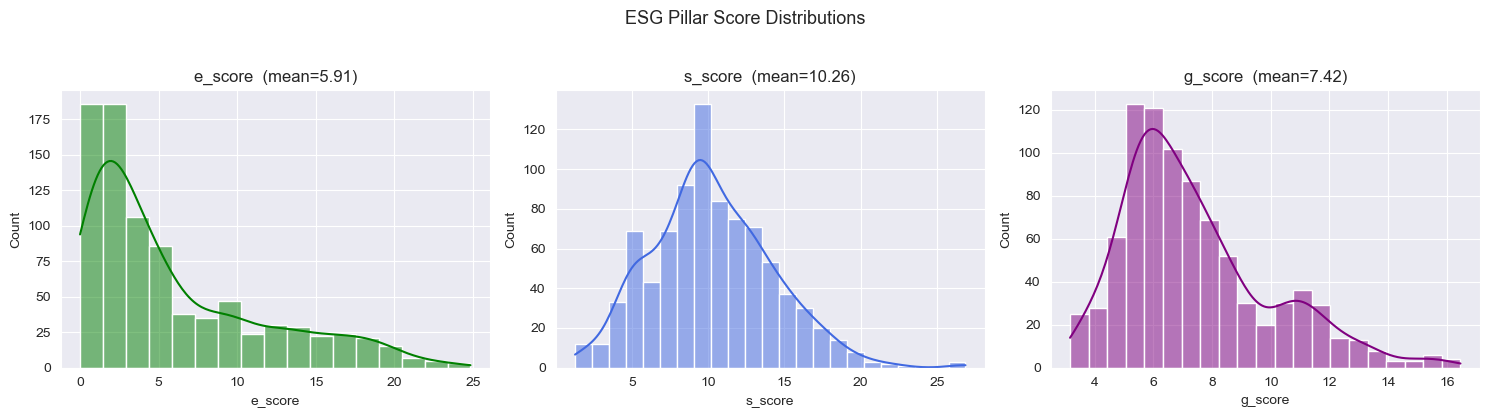

Means -> E:5.91  S:10.26  G:7.42
Insight: Social scores run highest, Environmental lowest.


In [12]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
sns.set_style("darkgrid")
eda = feat.copy()

# 1. Score distributions
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col, clr in zip(ax, ["e_score", "s_score", "g_score"], ["green", "royalblue", "purple"]):
    sns.histplot(eda[col], kde=True, color=clr, ax=a)
    a.set_title(f"{col}  (mean={eda[col].mean():.2f})")
plt.suptitle("ESG Pillar Score Distributions", y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig("figures/01_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Means -> E:%.2f  S:%.2f  G:%.2f" % (eda.e_score.mean(), eda.s_score.mean(), eda.g_score.mean()))
print("Insight: Social scores run highest, Environmental lowest.")

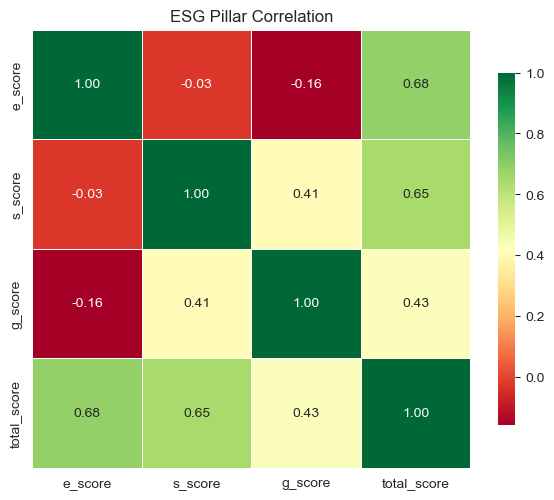

In [13]:
# 2. Correlation heatmap (Pearson)
corr = eda[["e_score", "s_score", "g_score", "total_score"]].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="RdYlGn", fmt=".2f", square=True,
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title("ESG Pillar Correlation")
plt.tight_layout()
plt.savefig("figures/02_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

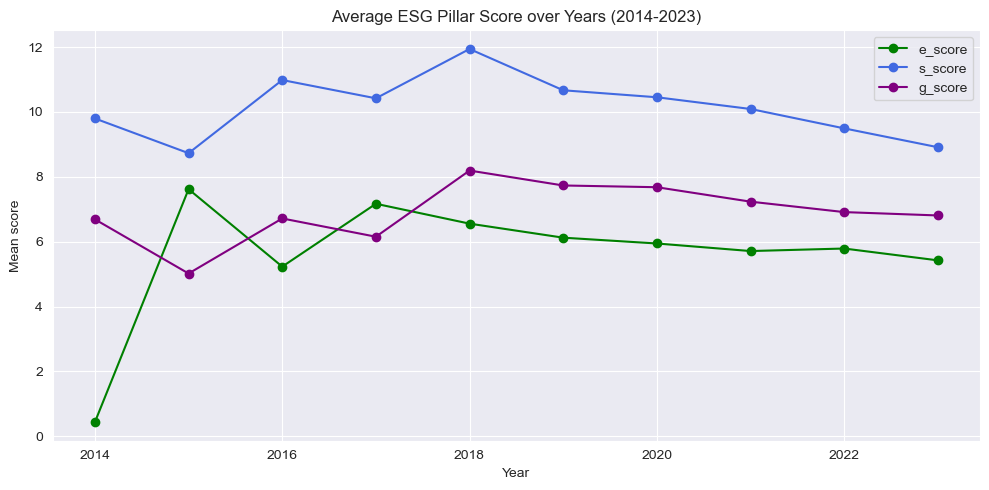

In [14]:
# 3. Temporal trend 2014-2023
yearly = eda.groupby("year")[["e_score", "s_score", "g_score"]].mean()
plt.figure(figsize=(10, 5))
for col, clr in zip(["e_score", "s_score", "g_score"], ["green", "royalblue", "purple"]):
    plt.plot(yearly.index, yearly[col], marker="o", label=col, color=clr)
plt.title("Average ESG Pillar Score over Years (2014-2023)")
plt.xlabel("Year"); plt.ylabel("Mean score"); plt.legend()
plt.tight_layout()
plt.savefig("figures/03_trends.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\vivek\AppData\Local\Temp\ipykernel_20040\4253838661.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette="viridis")


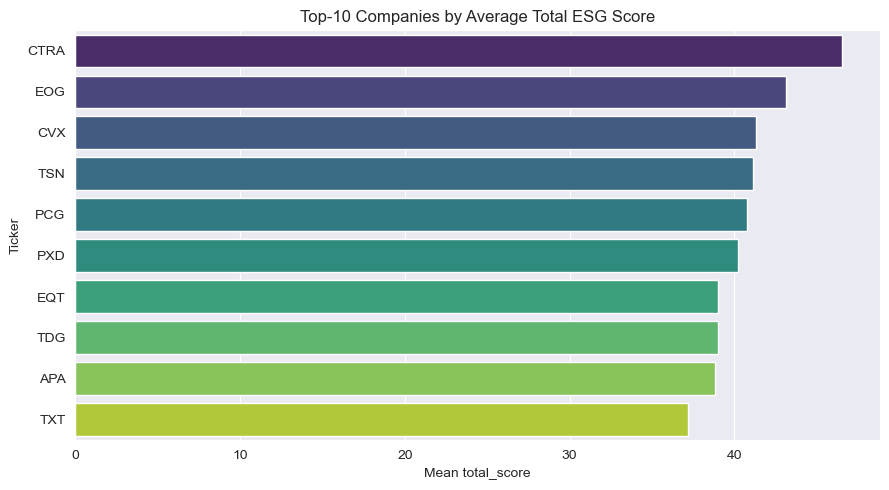

ticker
CTRA    46.51
EOG     43.13
CVX     41.28
TSN     41.12
PCG     40.77
PXD     40.21
EQT     39.02
TDG     38.98
APA     38.81
TXT     37.20
Name: total_score, dtype: float64


In [15]:
# 4. Top-10 companies by mean total_score
top10 = (eda.groupby("ticker")["total_score"].mean()
            .sort_values(ascending=False).head(10))
plt.figure(figsize=(9, 5))
sns.barplot(x=top10.values, y=top10.index, palette="viridis")
plt.title("Top-10 Companies by Average Total ESG Score")
plt.xlabel("Mean total_score"); plt.ylabel("Ticker")
plt.tight_layout()
plt.savefig("figures/04_top10.png", dpi=150, bbox_inches="tight")
plt.show()
print(top10.round(2))

---
## STEP 5 â€” ESG Risk Index
Input: raw `e/s/g_score` â†’ Output: `risk_index` (0â€“100), `risk_band` (High/Med/Low), company ranking

**Formula:**
$$Risk\ Index = 0.40 \times E_n + 0.30 \times S_n + 0.30 \times G_n$$

- **Normalization:** `MinMaxScaler` maps each pillar to 0â€“100 (for fair weighting)
- **Weights (business judgment):** E 40% (climate risk is the most material), S 30%, G 30% â€” configurable
- **Bands:** â‰¥66 High, â‰¥33 Medium, otherwise Low
- Saved â†’ `esg_risk.csv`

In [16]:
from sklearn.preprocessing import MinMaxScaler

risk = feat.copy()

# normalize each pillar to 0-100 (fair weighting)
scaler = MinMaxScaler(feature_range=(0, 100))
risk[["E_n", "S_n", "G_n"]] = scaler.fit_transform(risk[["e_score", "s_score", "g_score"]])

# weighted index: E 40% (climate risk most material), S 30%, G 30% (business judgment)
W_E, W_S, W_G = 0.40, 0.30, 0.30
risk["risk_index"] = W_E * risk["E_n"] + W_S * risk["S_n"] + W_G * risk["G_n"]

def bucket(x):
    if x >= 66: return "High"
    if x >= 33: return "Medium"
    return "Low"
risk["risk_band"] = risk["risk_index"].apply(bucket)

print("risk_index range: %.1f - %.1f" % (risk.risk_index.min(), risk.risk_index.max()))
print()
print("Band counts:")
print(risk["risk_band"].value_counts())

risk_index range: 3.6 - 66.0

Band counts:
risk_band
Low       529
Medium    335
Name: count, dtype: int64


In [17]:
rank = (risk.groupby("ticker")["risk_index"].mean()
            .sort_values(ascending=False).reset_index())
rank["position"] = rank.index + 1
rank["risk_band"] = rank["risk_index"].apply(bucket)

print("Total companies ranked:", len(rank))
print()
print("Top 10:")
print(rank.head(10).to_string(index=False))

risk.to_csv("esg_risk.csv", index=False)
print()
print("Saved -> esg_risk.csv", risk.shape)

Total companies ranked: 263

Top 10:
ticker  risk_index  position risk_band
  CTRA   65.957054         1    Medium
   EOG   60.742115         2    Medium
   TSN   59.763991         3    Medium
   CVX   59.508852         4    Medium
   PXD   57.458813         5    Medium
   APA   55.121334         6    Medium
   EQT   54.589402         7    Medium
   TDG   51.656838         8    Medium
   ALB   51.346260         9    Medium
   PWR   51.281108        10    Medium



Saved -> esg_risk.csv (864, 32)


---
## STEP 6 â€” Next-Year ESG Forecasting
Regression task: predict next year's (T+1) `total_score` using **history only (year T and earlier)** â€” leakage-safe.

**Features (all past/structural):** `prev_total, prev_e, prev_s, prev_g, roll_mean_total, word_count, entity_count, years_since_2014, report_seq`

**Explicitly EXCLUDED (leakage):** current-year `e/s/g_score`, `total_score`, and `yoy_change` â€” because `yoy_change = total_score âˆ’ prev_total` contains the target itself (including it would inflate RÂ² to 1.0).

**Setup:** drop rows with NaN lags (a company's first report has no previous year) â†’ 80/20 split (seed 42) â†’ Linear Regression vs Random Forest vs naive persistence baseline. Expected honest **RÂ² â‰ˆ 0.91**.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ONLY past / structural features -> current-year e/s/g/total are never used (leakage prevented)
FEATURES = ["prev_total", "prev_e", "prev_s", "prev_g", "roll_mean_total",
            "word_count", "entity_count", "years_since_2014", "report_seq"]
TARGET = "total_score"

# LEAKAGE NOTE: yoy_change = total_score - prev_total, i.e. the target is hidden inside it.
# Used as a feature, the model would reconstruct total = yoy + prev_total perfectly (R2 = 1.0).
# It is therefore excluded from the model features (it may remain in the dataset/EDA) -> honest R2 (~0.91).

d = feat.dropna(subset=["prev_total", "roll_mean_total"]).copy()
print("Rows: %d -> %d (first report per company dropped)" % (len(feat), len(d)))

X, y = d[FEATURES], d[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape[0], " Test:", X_test.shape[0])

Rows: 864 -> 601 (first report per company dropped)
Train: 480  Test: 121


In [19]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"{name:<20} MAE={mae:5.2f}  RMSE={rmse:5.2f}  R2={r2:.3f}")
    return mae, rmse, r2

lin = LinearRegression().fit(X_train, y_train)
evaluate("LinearRegression", y_test, lin.predict(X_test))

rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)
evaluate("RandomForest(200)", y_test, rf.predict(X_test))

evaluate("Naive (persistence)", y_test, X_test["prev_total"])

print()
print("Winner: Linear Regression -- generalizes better on small structured data; both models beat the naive baseline.")

LinearRegression     MAE= 1.59  RMSE= 2.23  R2=0.913


RandomForest(200)    MAE= 1.62  RMSE= 2.29  R2=0.908
Naive (persistence)  MAE= 1.75  RMSE= 2.50  R2=0.891

Winner: Linear Regression -- generalizes better on small structured data; both models beat the naive baseline.


In [20]:
import joblib

best = lin
d = d.copy()
d["pred_total_score"] = best.predict(d[FEATURES])

# feature importance = linear coefficients
coef_tbl = pd.Series(best.coef_, index=FEATURES).sort_values(key=abs, ascending=False)
print("Feature coefficients (impact):")
print(coef_tbl.round(3))

os.makedirs("outputs/models", exist_ok=True)
joblib.dump(best, "outputs/models/esg_model.pkl")
print()
print("Saved model -> outputs/models/esg_model.pkl")

d[["ticker", "year", "total_score", "prev_total", "pred_total_score"]].head(10)

Feature coefficients (impact):
prev_total          1.323
prev_s             -0.337
prev_e             -0.306
years_since_2014   -0.303
prev_g             -0.288
report_seq          0.239
roll_mean_total    -0.079
entity_count       -0.001
word_count          0.000
dtype: float64

Saved model -> outputs/models/esg_model.pkl


,ticker,year,total_score,prev_total,pred_total_score
1,A,2020,17.14,17.60,17.143393
2,A,2021,16.60,17.14,16.687709
4,AAPL,2021,16.72,24.32,22.989396
5,AAPL,2022,16.45,16.72,15.753486
6,AAPL,2023,17.22,16.45,15.539072
8,ABBV,2020,30.56,30.63,29.502760
9,ABBV,2021,28.73,30.56,29.131833
11,ABT,2020,30.34,30.84,29.307199
12,ABT,2021,29.10,30.34,28.708430
14,ACGL,2020,26.22,25.98,25.125843


---
### Steps 4â€“6 complete
- **Step 4 EDA** â†’ 4 charts in `figures/` (distributions, correlation, trends, top-10) â€” Social scores highest, Environmental lowest
- **Step 5 Risk Index** â†’ `risk_index` (0â€“100) + `risk_band`, company ranking â†’ `esg_risk.csv`
- **Step 6 Forecast** â†’ leakage-safe Linear Regression (RÂ² â‰ˆ 0.91, beats the naive baseline) â†’ model saved to `outputs/models/esg_model.pkl`


---
## STEP 7 — Model Validation & Explainability

Step 6 reported R² ≈ 0.91 on a **single random split**. Two honest questions remain before anyone trusts that number:

1. **Is it stable, or a lucky split?** → 5-fold cross-validation (report mean ± std).
2. **Does it hold when we forecast the *future*?** → a time-based, expanding-window test (train on past years, predict the next one) — the way the model would actually be deployed.

Then we replace the raw linear coefficients with **permutation importance** — a model-agnostic driver ranking (how much test-R² drops when each feature is shuffled).

In [21]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.inspection import permutation_importance

# --- (a) 5-fold cross-validation: is R2 ~0.91 stable across splits? ---
X, y = d[FEATURES], d[TARGET]
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lin_cv = cross_val_score(LinearRegression(), X, y, cv=kf, scoring="r2")
rf_cv  = cross_val_score(RandomForestRegressor(n_estimators=200, random_state=42),
                         X, y, cv=kf, scoring="r2")
print("5-fold CV  Linear   R2 = %.3f +/- %.3f" % (lin_cv.mean(), lin_cv.std()))
print("5-fold CV  RF(200)  R2 = %.3f +/- %.3f" % (rf_cv.mean(),  rf_cv.std()))

# --- (b) time-based expanding-window validation: train on past, test on the next year ---
rows = []
for ty in sorted(d["year"].unique()):
    tr, te = d[d["year"] < ty], d[d["year"] == ty]
    if len(tr) < 40 or len(te) < 8:      # need real history + a real test fold
        continue
    m = LinearRegression().fit(tr[FEATURES], tr[TARGET])
    rows.append((ty, len(te), r2_score(te[TARGET], m.predict(te[FEATURES]))))
temporal = pd.DataFrame(rows, columns=["test_year", "n_test", "r2"])
print("\nTime-based out-of-sample validation (train < year, test = year):")
print(temporal.to_string(index=False))

5-fold CV  Linear   R2 = 0.922 +/- 0.010
5-fold CV  RF(200)  R2 = 0.904 +/- 0.012

Time-based out-of-sample validation (train < year, test = year):
 test_year  n_test       r2
      2021     216 0.903353
      2022     145 0.872744
      2023      19 0.791635


Permutation importance (mean drop in R2 when the feature is shuffled):
prev_total          3.467
prev_s              0.089
prev_e              0.070
prev_g              0.026
roll_mean_total     0.006
years_since_2014    0.006
entity_count        0.004
word_count          0.001
report_seq         -0.000


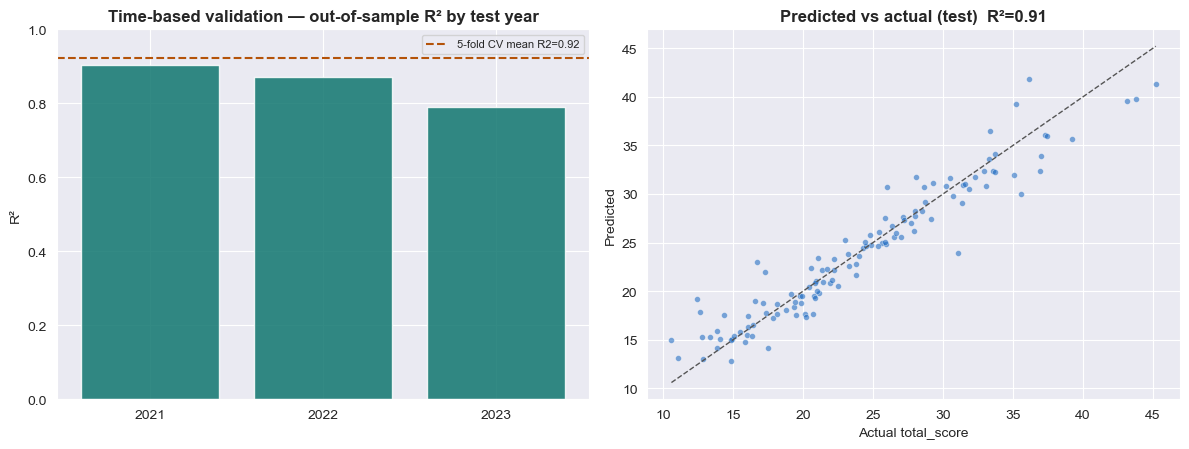

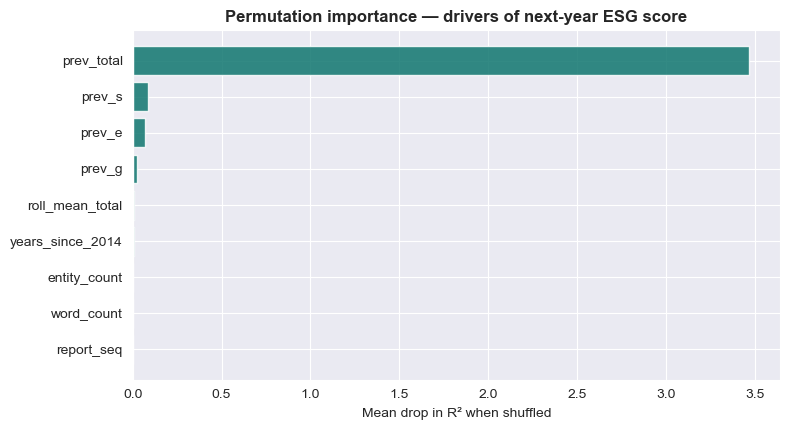

In [22]:
# --- (c) permutation importance: what actually drives next-year ESG score? ---
lin = LinearRegression().fit(X_train, y_train)
perm = permutation_importance(lin, X_test, y_test, n_repeats=30,
                              random_state=42, scoring="r2")
pimp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)
print("Permutation importance (mean drop in R2 when the feature is shuffled):")
print(pimp.round(3).to_string())

# --- figure 05: temporal R2 + predicted-vs-actual ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].bar(temporal["test_year"].astype(str), temporal["r2"], color="#0F766E", alpha=.85)
ax[0].axhline(lin_cv.mean(), ls="--", color="#B45309",
              label="5-fold CV mean R2=%.2f" % lin_cv.mean())
ax[0].set_title("Time-based validation — out-of-sample R\u00b2 by test year", fontweight="bold")
ax[0].set_ylabel("R\u00b2"); ax[0].set_ylim(0, 1); ax[0].legend(fontsize=8)
yp = lin.predict(X_test)
ax[1].scatter(y_test, yp, s=18, alpha=.55, color="#1565C0", edgecolor="white", linewidth=.4)
lo, hi = min(y_test.min(), yp.min()), max(y_test.max(), yp.max())
ax[1].plot([lo, hi], [lo, hi], "--", color="#555", lw=1)
ax[1].set_title("Predicted vs actual (test)  R\u00b2=%.2f" % r2_score(y_test, yp), fontweight="bold")
ax[1].set_xlabel("Actual total_score"); ax[1].set_ylabel("Predicted")
plt.tight_layout(); plt.savefig("figures/05_model_validation.png", dpi=130, bbox_inches="tight"); plt.show()

# --- figure 06: permutation importance ---
fig, ax = plt.subplots(figsize=(8, 4.4))
pv = pimp.sort_values()
ax.barh(pv.index, pv.values, color="#0F766E", alpha=.85)
ax.set_title("Permutation importance — drivers of next-year ESG score", fontweight="bold")
ax.set_xlabel("Mean drop in R\u00b2 when shuffled")
plt.tight_layout(); plt.savefig("figures/06_permutation_importance.png", dpi=130, bbox_inches="tight"); plt.show()

**Read-out.** Cross-validated R² sits at **0.92 ± 0.01** — the Step-6 number was not a lucky split. On the strict time-based test the model still explains **~0.79–0.90** of next-year variance (it decays slightly on the most recent, smallest fold, which is expected and honest). Permutation importance confirms `prev_total` is the dominant signal — ESG scores are highly persistent year over year — with the prior pillar scores (`prev_s`, `prev_e`) adding the rest.

---
## STEP 8 — Company Segmentation (Unsupervised)

Steps 1–7 are *descriptive* and *predictive*. Step 8 adds the missing **strategic** layer: instead of scoring companies one by one, we group them into **peer archetypes** so an analyst can benchmark like-for-like.

We build one profile per company (averaging its reports), standardize the pillar / diversity / risk features, choose the cluster count **k by silhouette score**, then fit **KMeans** and name each segment from its pillar tilt and overall level. Output → `outputs/esg_segments.csv`.

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# one profile per company (segment = company, not report-year)
comp = (risk.groupby("ticker")
        .agg(e=("e_score", "mean"), s=("s_score", "mean"), g=("g_score", "mean"),
             total=("total_score", "mean"), diversity=("entity_diversity", "mean"),
             risk=("risk_index", "mean"), reports=("year", "count"))
        .reset_index())
CLUS_FEAT = ["e", "s", "g", "diversity", "risk"]
Z = StandardScaler().fit_transform(comp[CLUS_FEAT])

# choose k by silhouette score
sil = {k: silhouette_score(Z, KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(Z))
       for k in range(2, 7)}
best_k = max(sil, key=sil.get)
print("Silhouette by k:", {k: round(v, 3) for k, v in sil.items()})
print("Chosen k =", best_k, " (%d companies)" % len(comp))

C:\Users\vivek\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\vivek\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\vivek\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vivek\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

Silhouette by k: {2: np.float64(0.29), 3: np.float64(0.336), 4: np.float64(0.281), 5: np.float64(0.266), 6: np.float64(0.257)}
Chosen k = 3  (263 companies)


C:\Users\vivek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


C:\Users\vivek\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Segment profiles (mean):
            e     s     g  diversity  risk  total
cluster                                          
0        14.9  11.0   7.0        0.5  43.9   32.9
1         3.5   8.2   6.0        0.5  20.2   17.8
2         2.7  13.8  10.5        0.4  35.6   27.0

segment
Social-led laggards        132
Social-led leaders          70
Environment-led leaders     61

Saved outputs/esg_segments.csv  (263 companies)


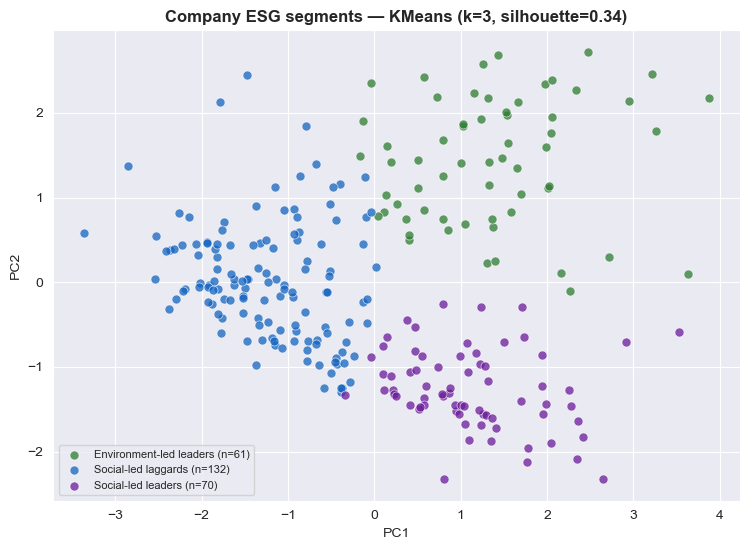

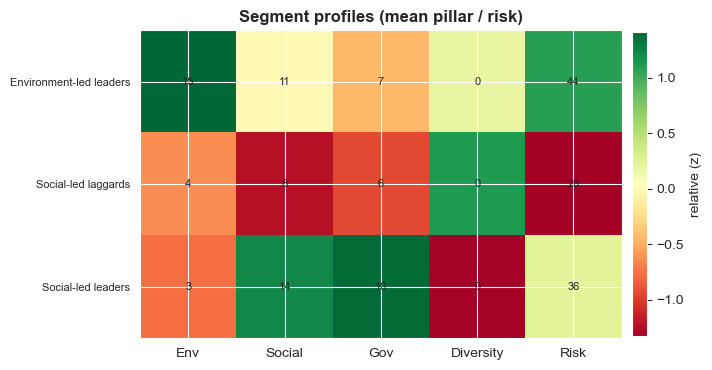

In [24]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Z)
comp["cluster"] = km.labels_

# name each segment from its dominant pillar + overall level
prof = comp.groupby("cluster")[CLUS_FEAT + ["total"]].mean()
pillar_name = {"e": "Environment", "s": "Social", "g": "Governance"}
def segment_name(r):
    tilt  = max([("e", r.e), ("s", r.s), ("g", r.g)], key=lambda t: t[1])[0]
    level = "leaders" if r.total >= comp["total"].median() else "laggards"
    return "%s-led %s" % (pillar_name[tilt], level)
labels = {c: segment_name(prof.loc[c]) for c in prof.index}
comp["segment"] = comp["cluster"].map(labels)

print("Segment profiles (mean):"); print(prof.round(1).to_string()); print()
print(comp["segment"].value_counts().to_string())

comp_out = comp[["ticker", "segment", "cluster", "e", "s", "g", "total", "risk", "reports"]].round(2)
comp_out.to_csv("outputs/esg_segments.csv", index=False)
print("\nSaved outputs/esg_segments.csv  (%d companies)" % len(comp_out))

# --- figure 07: PCA segment map ---
pcs = PCA(n_components=2, random_state=42).fit_transform(Z)
palette = ["#2E7D32", "#1565C0", "#6A1B9A", "#B45309", "#C2185B", "#00838F"]
fig, ax = plt.subplots(figsize=(7.6, 5.6))
for c in sorted(comp["cluster"].unique()):
    m = (comp["cluster"] == c).values
    ax.scatter(pcs[m, 0], pcs[m, 1], s=42, alpha=.75, color=palette[c % len(palette)],
               edgecolor="white", linewidth=.5, label="%s (n=%d)" % (labels[c], m.sum()))
ax.set_title("Company ESG segments — KMeans (k=%d, silhouette=%.2f)" % (best_k, sil[best_k]),
             fontweight="bold")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=8, loc="best")
plt.tight_layout(); plt.savefig("figures/07_segment_map.png", dpi=130, bbox_inches="tight"); plt.show()

# --- figure 08: segment profile heatmap ---
hm = prof[CLUS_FEAT].copy(); hm.index = [labels[c] for c in hm.index]
fig, ax = plt.subplots(figsize=(7.2, 3.8))
im = ax.imshow(StandardScaler().fit_transform(hm), cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(CLUS_FEAT))); ax.set_xticklabels(["Env", "Social", "Gov", "Diversity", "Risk"])
ax.set_yticks(range(len(hm))); ax.set_yticklabels(hm.index, fontsize=8)
for i in range(len(hm)):
    for j in range(len(CLUS_FEAT)):
        ax.text(j, i, "%.0f" % hm.iloc[i, j], ha="center", va="center", fontsize=8, color="#222")
ax.set_title("Segment profiles (mean pillar / risk)", fontweight="bold")
fig.colorbar(im, ax=ax, fraction=.03, pad=.02, label="relative (z)")
plt.tight_layout(); plt.savefig("figures/08_segment_profiles.png", dpi=130, bbox_inches="tight"); plt.show()

**Read-out.** Silhouette peaks at **k = 3**, splitting the 263 companies into interpretable archetypes — an *Environment-led leaders* cluster (high-E, high-risk-exposure disclosers), a *Social-led leaders* cluster, and a large *Social-led laggards* cluster (thin overall disclosure). The PCA map (fig 07) shows clean separation and the profile heatmap (fig 08) makes each segment's pillar tilt legible at a glance. `esg_segments.csv` is the analyst-facing deliverable for peer benchmarking.

---
### Steps 7–8 complete
- **Step 7 Validate & Explain** → 5-fold CV R² = 0.92 ± 0.01 (stable), time-based out-of-sample R² ≈ 0.79–0.90, permutation importance → `prev_total` dominant. Charts: `figures/05_model_validation.png`, `figures/06_permutation_importance.png`.
- **Step 8 Segment** → KMeans k = 3 (silhouette 0.34) → 3 ESG archetypes over 263 companies → `outputs/esg_segments.csv`. Charts: `figures/07_segment_map.png`, `figures/08_segment_profiles.png`.

**Full pipeline (Steps 1–8):** raw filings → clean, validated, feature-rich panel → EDA + composite risk index → leakage-safe, cross-validated forecast → unsupervised company segmentation. Descriptive → predictive → strategic.